### Create multi feature data set

In [2]:
import numpy as np

np.random.seed(42)

n = 200
X1 = np.random.uniform(0, 10, n)
X2 = np.random.uniform(0, 5, n)

# True function
Y = 3*X1 + 2*X2 + np.random.normal(0, 2, n)

X = np.column_stack((X1, X2))
X

array([[3.74540119, 3.21015823],
       [9.50714306, 0.42069982],
       [7.31993942, 0.80814357],
       [5.98658484, 4.49277094],
       [1.5601864 , 3.0321453 ],
       [1.5599452 , 0.04598526],
       [0.58083612, 0.50735771],
       [8.66176146, 3.31750885],
       [6.01115012, 0.02530792],
       [7.08072578, 0.80404026],
       [0.20584494, 2.74366895],
       [9.69909852, 3.45947599],
       [8.32442641, 3.2598063 ],
       [2.12339111, 1.12134655],
       [1.81824967, 3.56089611],
       [1.8340451 , 1.18624544],
       [3.04242243, 1.62699849],
       [5.24756432, 3.73245703],
       [4.31945019, 3.2481645 ],
       [2.9122914 , 4.24611705],
       [6.11852895, 3.28806446],
       [1.39493861, 2.84154302],
       [2.92144649, 0.46837384],
       [3.66361843, 1.83857902],
       [4.56069984, 1.32601184],
       [7.85175961, 1.21994822],
       [1.99673782, 4.86505277],
       [5.14234438, 1.96548862],
       [5.92414569, 4.46023278],
       [0.46450413, 3.15569313],
       [6.

### Train test Split

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

### Convert to DMatrix (memory efficient)

In [6]:
from xgboost import DMatrix

dtrain = DMatrix(X_train, label=y_train)

dtest = DMatrix(X_test, label=y_test)

print(type(dtrain))

<class 'xgboost.core.DMatrix'>


### Train the model


 MODEL 1

--- Predictions (first 5) ---
[16.061071 22.98711  21.865292 18.930265 18.01325 ]

--- Residuals (first 5) ---
[-0.96415538  8.11566172  6.83174141 -1.77027931  1.38605876]

--- Similarity Score ---
0.0136


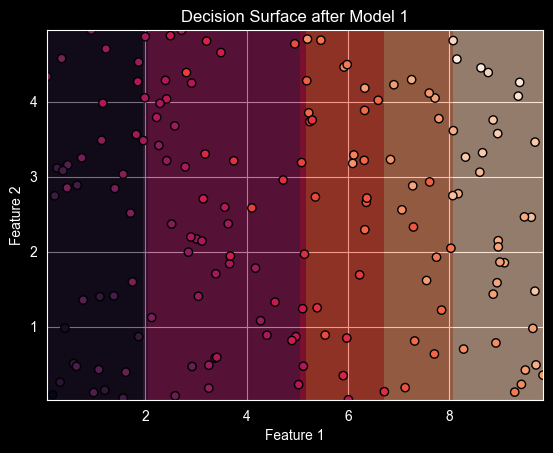


 MODEL 2

--- Predictions (first 5) ---
[13.408663 25.690107 23.268726 18.674902 16.763863]

--- Residuals (first 5) ---
[ 1.68825322  5.41266451  5.42830665 -1.51491585  2.6354465 ]

--- Similarity Score ---
0.0867


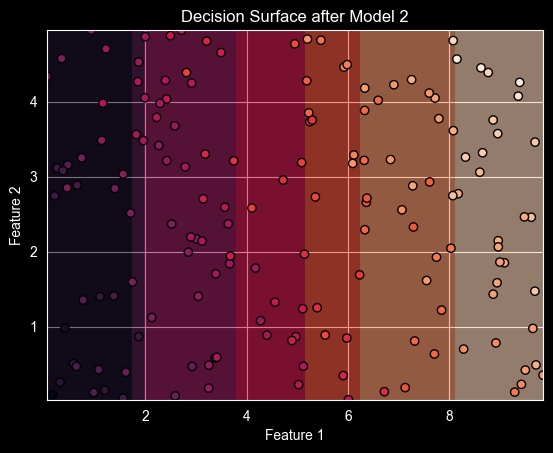


 MODEL 3

--- Predictions (first 5) ---
[14.731765 25.731998 23.310617 17.55697  16.805754]

--- Residuals (first 5) ---
[ 0.36515122  5.37077341  5.38641555 -0.39698448  2.5935554 ]

--- Similarity Score ---
0.4626


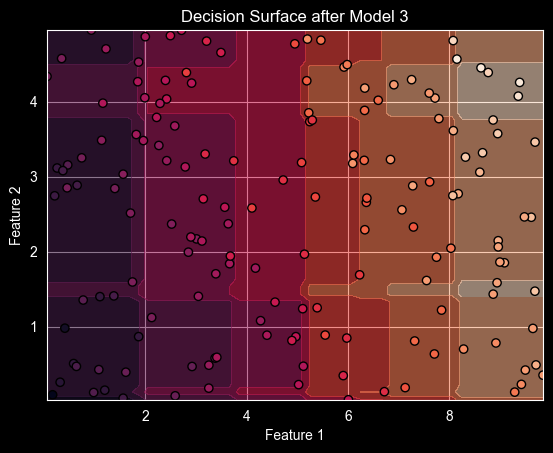


 MODEL 4

--- Predictions (first 5) ---
[15.57678  25.901632 24.155632 16.602987 17.650768]

--- Residuals (first 5) ---
[-0.47986431  5.20113954  4.54140098  0.55699882  1.74854083]

--- Similarity Score ---
0.0791


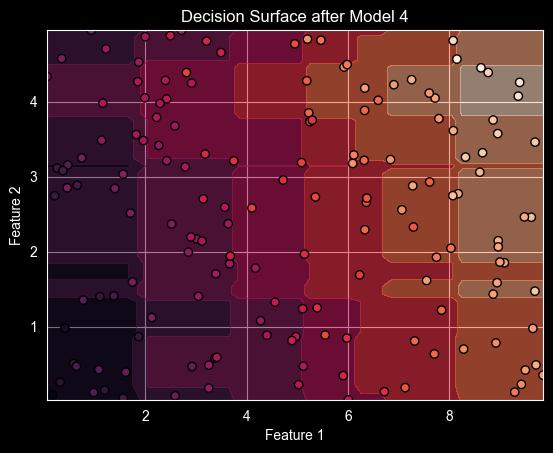


 MODEL 5

--- Predictions (first 5) ---
[15.053251 26.00299  24.25699  16.704346 17.752127]

--- Residuals (first 5) ---
[0.04366475 5.09978113 4.44004257 0.45564041 1.64718241]

--- Similarity Score ---
0.3017


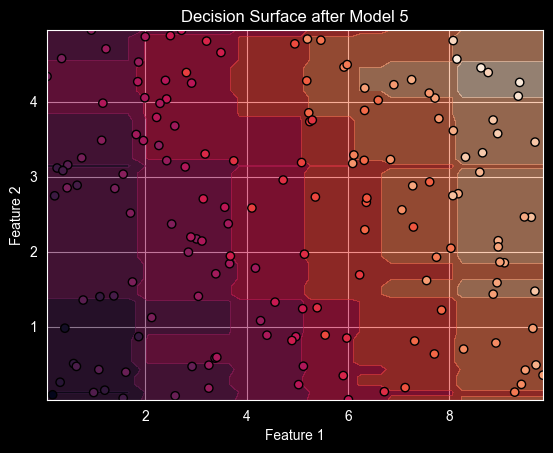

In [18]:
from matplotlib import pyplot as plt
from xgboost import train

params = {
    'objective': 'reg:squarederror',
    'max_depth': 3,
    'eta': 0.3,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'tree_method': 'hist',
    'nthread': -1
}

num_round = 5
model = None

# ------------------------------
# 5. Training Loop (STRICT step-by-step)
# ------------------------------
for i in range(1, num_round+1):
    print(f"\n==============================")
    print(f" MODEL {i}")
    print(f"==============================")

    model = train(params, dtrain, num_boost_round=i)

    # Predictions
    y_pred = model.predict(dtrain)

    # Residuals
    residuals = y_train - y_pred

    # Similarity Score
    G = np.sum(residuals)
    H = len(residuals)
    lam = 1
    similarity_score = (G**2) / (H + lam)

    # PRINT EVERYTHING
    print("\n--- Predictions (first 5) ---")
    print(y_pred[:5])

    print("\n--- Residuals (first 5) ---")
    print(residuals[:5])

    print(f"\n--- Similarity Score ---\n{similarity_score:.4f}")

    # --------------------------
    # Decision Boundary (Surface)
    # --------------------------
    x1_range = np.linspace(X_train[:,0].min(), X_train[:,0].max(), 50)
    x2_range = np.linspace(X_train[:,1].min(), X_train[:,1].max(), 50)

    xx, yy = np.meshgrid(x1_range, x2_range)
    grid = np.c_[xx.ravel(), yy.ravel()]

    dgrid = DMatrix(grid)
    zz = model.predict(dgrid).reshape(xx.shape)

    plt.figure()
    plt.contourf(xx, yy, zz, alpha=0.6)
    plt.scatter(X_train[:,0], X_train[:,1], c=y_train, edgecolors='k')
    plt.title(f"Decision Surface after Model {i}")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

### Final score

In [19]:
y_test_pred = model.predict(dtest)
sse = np.sum((y_test - y_test_pred)**2)

print("\n==============================")
print(" FINAL RESULT")
print("==============================")
print(f"SSE (Test Data): {sse:.4f}")


 FINAL RESULT
SSE (Test Data): 1109.8238


## Lets calculate r2 score

In [15]:
from sklearn.metrics import r2_score
r2_score(y_test, y_test_pred)

0.6970287464032594